# Statistics for WLASL: Pre-processed

In [1]:
from typing import List, cast
import json
from pathlib import Path
import matplotlib.pyplot as plt
#locals
from configs import WLASL_ROOT, SPLIT_DIR, CLASSES_PATH, LABELS_PATH, LABEL_SUFFIX
import stats
import preprocess as preproc

## From the WLASL GitHUB page

Data Description
-----------------

* `gloss`: *str*, data file is structured/categorised based on sign gloss, or namely, labels.

* `bbox`: *[int]*, bounding box detected using YOLOv3 of (xmin, ymin, xmax, ymax) convention. Following OpenCV convention, (0, 0) is the up-left corner.

* `fps`: *int*, frame rate (=25) used to decode the video as in the paper.

* `frame_start`: *int*, the starting frame of the gloss in the video (decoding
with FPS=25), *indexed from 1*.

* `frame_end`: *int*, the ending frame of the gloss in the video (decoding with FPS=25). -1 indicates the gloss ends at the last frame of the video.

* `instance_id`: *int*, id of the instance in the same class/gloss.

* `signer_id`: *int*, id of the signer.

* `source`: *str*, a string identifier for the source site.

* `split`: *str*, indicates sample belongs to which subset.

* `url`: *str*, used for video downloading.

* `variation_id`: *int*, id for dialect (indexed from 0).

* `video_id`: *str*, a unique video identifier.


### Additional info:

* The videos come pre-cut from the original youtube videos, therefore, the video_id is essentially a unique identifier for each instance

* There are some issues with the labelling, especially where certain frame start and ends are way too high. These are set to 0 and last frame respectively


* All precut video clips have a width and height of 256 pixels. 

* Modified bounding boxes with yolov8


### Naming convention:
For the naming of different functions, 'set' and 'split' can somtimes be used interchangibly to mean different things, which can be confusing. So for all code written by me,
* **SPLIT**: A split of WLASL, one of asl100, asl300, asl1000 and asl2000
* **SET**: A subset of a given wlasl split, one of train, val test


# TODO:
- make a flag to control preprocessed vs unprocessed
- add removed instances
- add bounding box info

## Split

#### Pick split

In [2]:
split_idx = 3 #change for different split

split_options: List[stats.AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000"]
print('Options:')
for i, split_name in enumerate(split_options):
    print(f'{i} : {split_name}')
    
print()
split_name: stats.AVAIL_SPLITS = split_options.pop(split_idx)
print(f'Selected: {split_name}')

Options:
0 : asl100
1 : asl300
2 : asl1000
3 : asl2000

Selected: asl2000


In [3]:
labels_dir = Path(LABELS_PATH) 
split_dir = labels_dir / split_name

with open(CLASSES_PATH, 'r') as f:
    classes = json.load(f)
    
preprocessed_split_dir = Path(WLASL_ROOT) / SPLIT_DIR
with open(preprocessed_split_dir / f'{split_name}.json', 'r') as f:
    unproc_split = json.load(f)

## Set

#### Pick set

In [4]:
set_idx = 1

set_options: List[stats.AVAIL_SETS] = ['train', 'test', 'val']
print('Options:')
for i, set_name in enumerate(set_options):
    print(f'{i} : {set_name}')
    
print()
set_name: stats.AVAIL_SETS = set_options.pop(set_idx)
print(f'Selected: {set_name}')

Options:
0 : train
1 : test
2 : val

Selected: test


Preprocessed

In [5]:
set_info = stats.retrieve_split_data(split=split_name, labels_dir=labels_dir, pattern=f'{set_name}_instances*.json')
# removed_info = stats.retrieve_split_data(split=split_name, labels_dir=labels_dir, pattern=f'*{set_name}.json')

print(f'Set info for {split_name}/{set_name}')
for cnt, (key, value) in enumerate(set_info.items()):
    assert cnt != 1, 'Too many entries found'
    print(f'File path: {key}')
    preproc_set = [preproc.Instance.model_validate(c) for c in value]
    print(f'Num instances: {len(preproc_set)}\n')


Set info for asl2000/test
File path: test_instances_fixed_frange_bboxes_len.json
Num instances: 2879



In [6]:
wlasl_order_preproc_set = stats.reverse_preproc_format(preproc_instances=preproc_set)
ex_sample = wlasl_order_preproc_set[0]
print(f'gloss: {ex_sample["gloss"]}')
print(f'Num instances: {len(ex_sample["instances"])}')

gloss: book
Num instances: 4


## Stats

In [7]:
figsize = (14, 4)
bins = 24

#### Example

In [8]:
ex_idx = 0
# ex_gloss = current_set[ex_idx]
set_instances = preproc_set
# print(f"Gloss label: {ex_gloss['gloss']}")

In [9]:
set_stats = stats.collect_instance_stats(set_instances)
print('Available keys: ')
for key in set_stats:
    print(f'- {key}')

Available keys: 
- num_instances
- length_distribution
- signers_distribution
- source_distribution
- url_distribution
- variation_distribution


Number of videos:

In [10]:
print(f"Num instances: {set_stats['num_instances']}")

Num instances: 2879


In [11]:
metrics = ("Video length", "Signer", "Video Source", "Video")
units = ("frames", "id", "YouTube Channel/Website", "url")
freq_metrics = (f"Frequency of {metric} appearences" for metric in metrics)

In [12]:
print(set_stats.keys())

dict_keys(['num_instances', 'length_distribution', 'signers_distribution', 'source_distribution', 'url_distribution', 'variation_distribution'])


Video length distribution
132


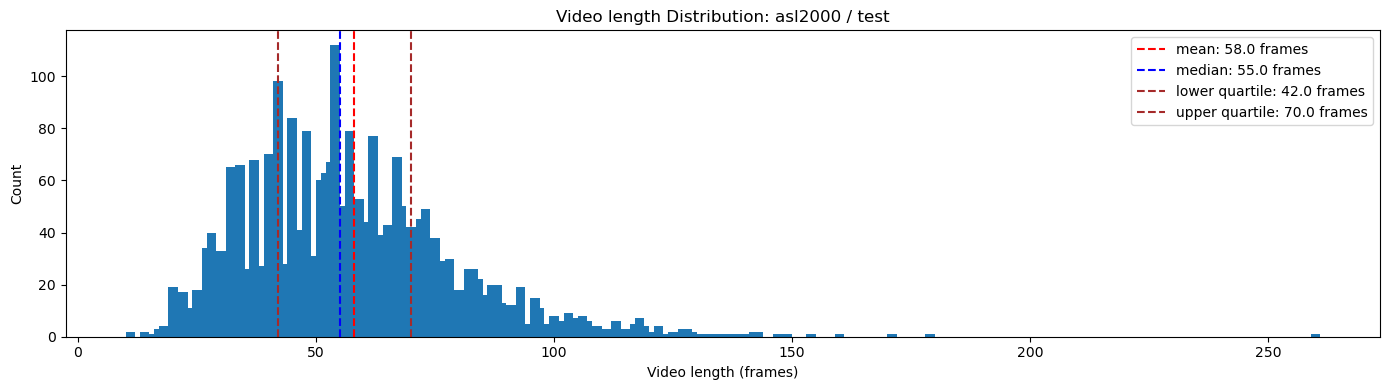

Frequency of video length appearences distribution
58


/home/luke/Code/SLR/code/stats.py:468: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


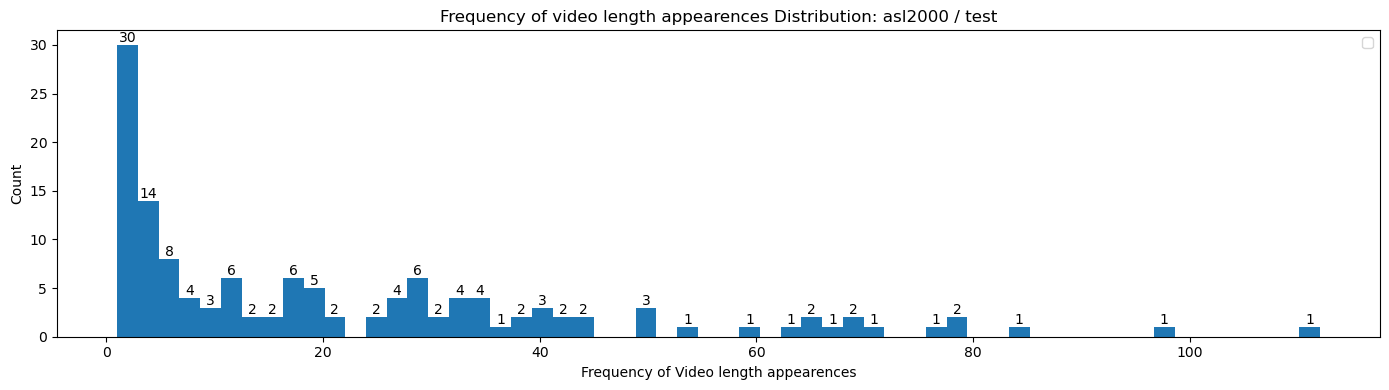

Signer distribution
105


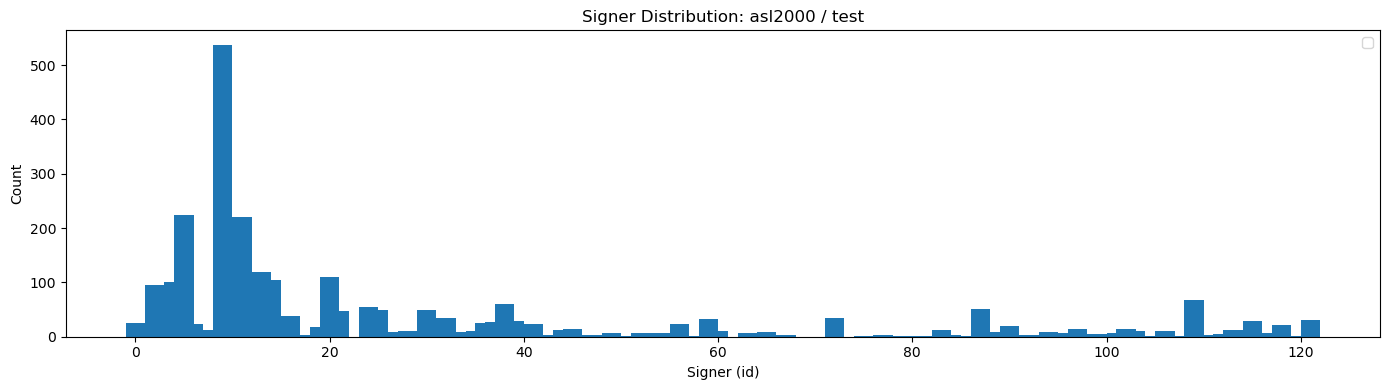

Frequency of signer appearences distribution
45


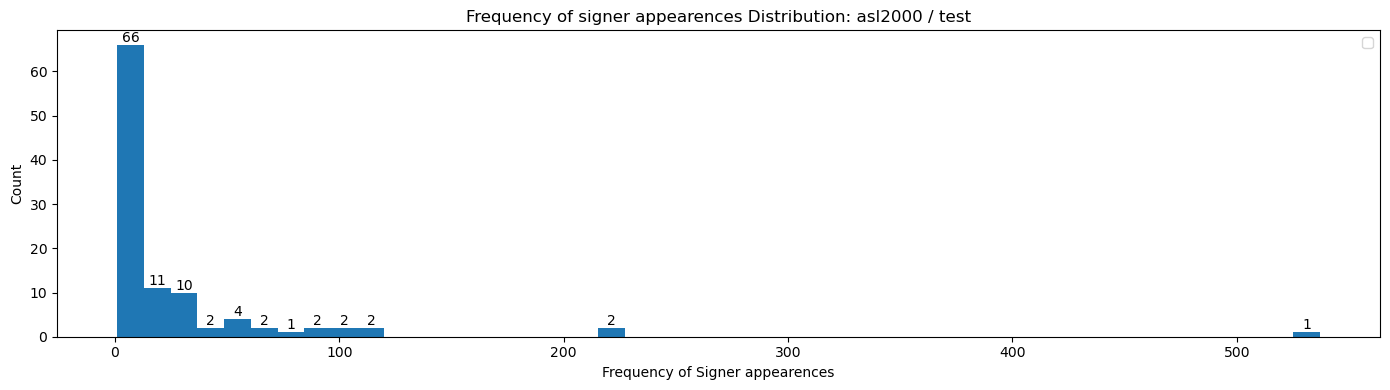

Video source distribution
19


/home/luke/Code/SLR/code/stats.py:468: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


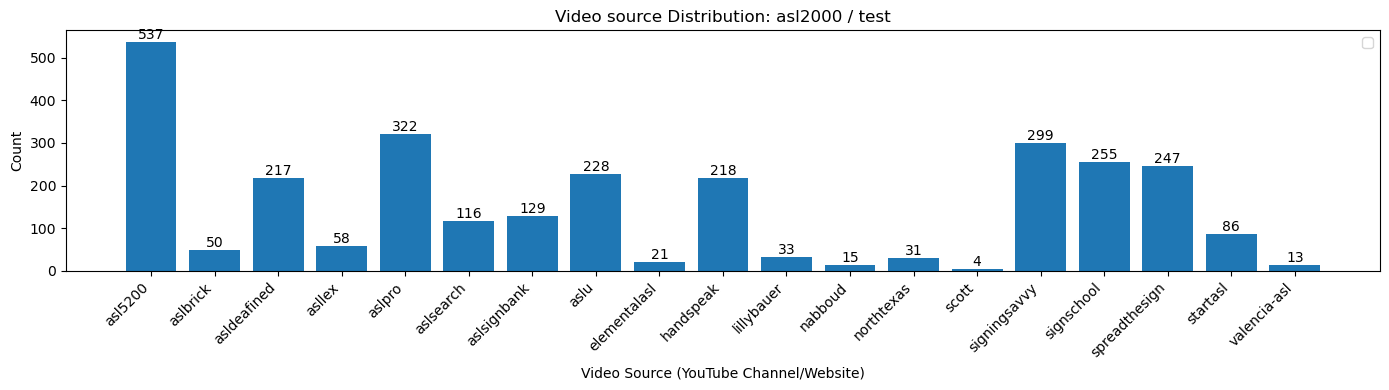

Frequency of video source appearences distribution
19


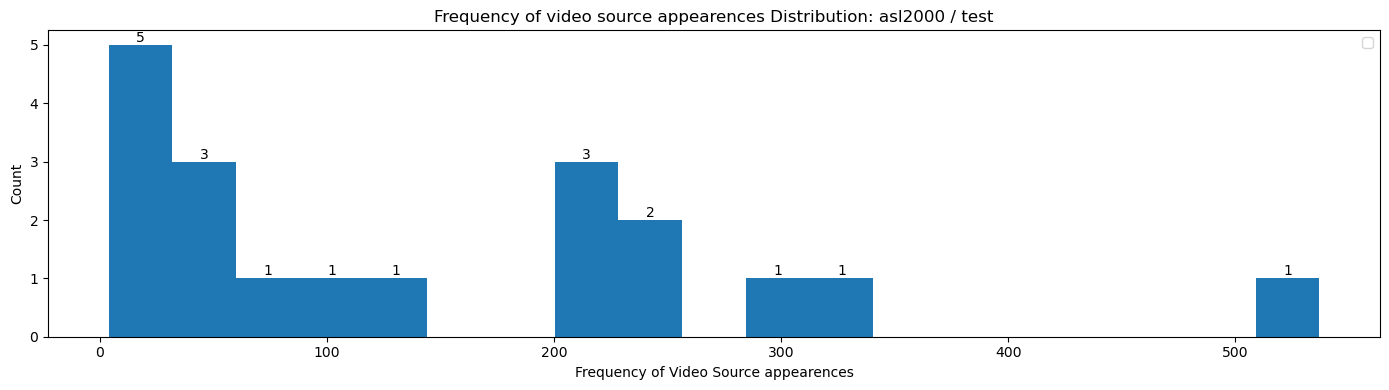

Video distribution
2316
Frequency of video appearences distribution
6


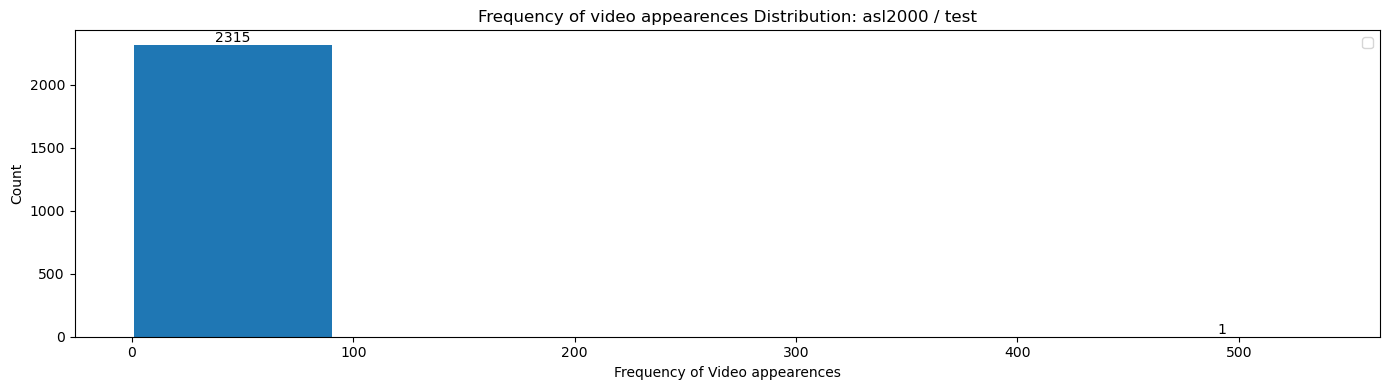

In [13]:


for key, metric, unit, freq_metric in zip(
    list(set_stats.keys())[1:], metrics, units, freq_metrics
):
    print(f"{metric.capitalize()} distribution")
    # Distribution of metric
    histogram = set_stats[key]
    print(len(histogram))
    # if unit != 'url':
    if metric != 'Video':
        stats.plot_distribution(
            histogram,
            set_name=set_name,
            split_name=split_name,
            metric=metric,
            unit=unit,
            categorical=(metric != "Video length" and metric != 'Signer' ),
            figsize=figsize,
            # bins=bins,
            bins=len(histogram),
            hist_or_bar='bar',
            show_nums_on_bars=(metric != "Video length" and metric != 'Signer'),
            no_statsy_lines=metric == 'Signer',
            out_path=f"./media/seminar1/{metric}_{split_name}_{set_name}.svg"
        )
    # Distribution of counts, of Distribution of metric
    # For example, if the above is the distribution of how many times each
    # signer id appeared, a single sample may be 1 appearence. Then below
    # is the distribution of how many times a signer appeared x times, a
    # single sample may be how many times signers appeared only once.
    print(f'{freq_metric.capitalize()} distribution')
    count_frequencies = stats.make_histogram(histogram.values())
    print(len(count_frequencies))
    # if unit != 'url':
    
    
    if True:
        stats.plot_distribution(
            count_frequencies,
            set_name=set_name,
            split_name=split_name,
            metric=freq_metric,
            categorical=False,
            # categorical=True,
            figsize=figsize,
            # bins=bins,
            bins=len(count_frequencies),
            hist_or_bar='hist',
            # hist_or_bar='bar'
            out_path=f"./media/seminar1/freq_{metric}_{split_name}_{set_name}.svg"
        )
        
    # plt.savefig(f"./media/freq_{metric}_{split_name}_{set_name}.svg")

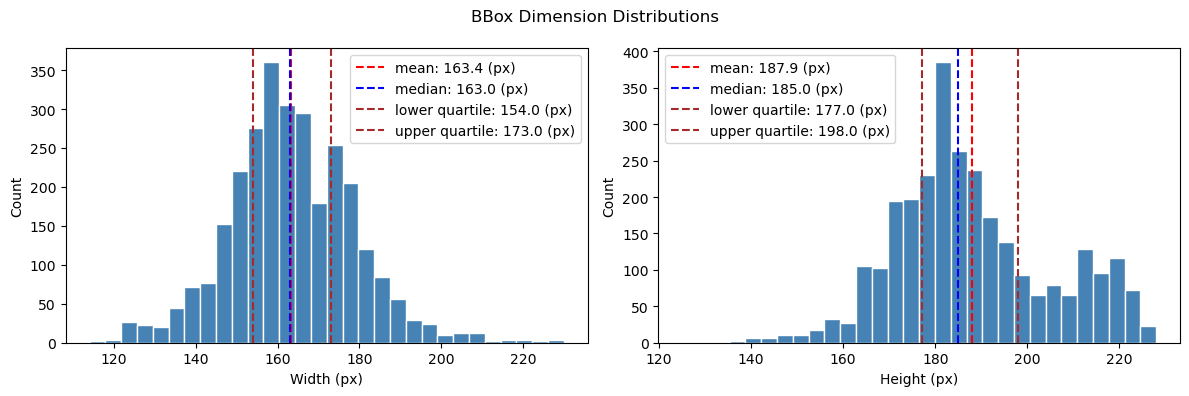

In [14]:
stats.plot_dimension_distributions(set_instances)

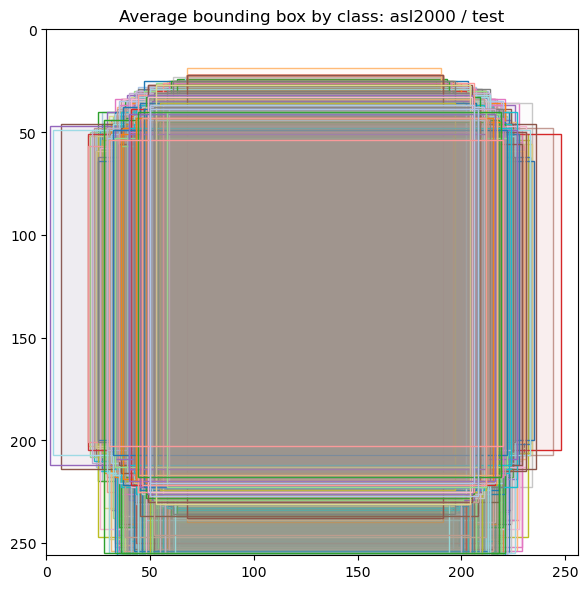

In [15]:
metric = 'bboxes'

stats.plot_bboxes_on_canvas(set_instances, 
                            title=f'Average bounding box by class: {split_name} / {set_name}',
                            out_path=f"./media/seminar1/{metric}_{split_name}_{set_name}.svg")